# 13 · 직접 쓴 미분을 자동미분 그래프로 연결하기

**이번 질문:** 지금까지 층마다 손으로 쓴 backward를, 연산마다의 국소 미분만 적어 두면 기계가 알아서 이어 주게 할 수 있을까요? 그렇게 만든 기울기가 손으로 쓴 것, PyTorch, 중심차분과 같을까요?

NumPy 배열을 담는 작은 `Node`를 만들고, 연산의 국소 미분(VJP)을 연결해 MLP를 학습합니다. 같은 가중치에서 손으로 쓴 backward·이 엔진·PyTorch·중심차분을 비교합니다.
핵심 코드는 모두 본문에 있습니다.

- 준비물: [01](../00_기초/01_gradients_and_learning.ipynb)의 연쇄법칙, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 MLP backward, [08](../01_아키텍처/08_attention.ipynb)의 Jacobian.
- 도착점: VJP·broadcast 역방향·위상 순서를 직접 쓰고, 새 연산을 그래프에 붙여 전체 MLP 검산을 통과시킵니다.
- 다음 연결: [14 손실·정규화](14_losses_regularization.ipynb)에서는 계산할 목적을 바꿉니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 자동미분은 연산마다 "뒤에서 온 기울기 $g$를 입력 쪽으로 옮기는 규칙" $dx=J^\top g$(VJP)만 알면 됩니다. 전체 Jacobian은 만들지 않습니다. 같은 값이 여러 경로에 쓰였으면 기여를 **더합니다**.
2. broadcasting의 역방향은 합입니다. $(D,)$를 $(N,D)$로 복사해 썼으면 `dY.sum(axis=0)`, 길이 1이던 축은 `keepdims=True`로 합칩니다.
3. `Node`는 값·부모·pullback을 들고, 위상 순서(부모 먼저)를 뒤집어 backward를 돕니다. 스텝마다 그래프를 새로 만들고, backward 뒤에 파라미터를 갱신합니다. PyTorch는 `.grad`를 누적하므로 `zero_grad`가 필요합니다.

📎 이 단원의 PyTorch 비교 셀은 CPU의 `float64`를 사용합니다. 프로젝트 최상위에서 `python -m pip install -e '.[dev,framework]'`로 실행 환경을 준비할 수 있습니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/autodiff_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/utils/plotting.py').is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, PyTorch(4절 비교용), 수치미분 도우미(중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 이 노트북의 그림 함수(src/utils/autodiff_plots.py)
import numpy as np
import torch
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.utils.autodiff_plots import (
    plot_curves, plot_shared_path, plot_vjp, plot_broadcast_backward, plot_mlp_graph, plot_local_rules,
    plot_training_cycle, plot_fit, plot_stop_gradient,
)

# 3) 그림 설정
setup_plots()
print('NumPy:', np.__version__, 'PyTorch:', torch.__version__, '비교 장치: CPU, dtype: float64')

NumPy: 2.4.6 PyTorch: 2.14.0 비교 장치: CPU, dtype: float64


### 📎 이 노트북의 예시: 손계산 그래프, 작은 MLP, sin 회귀

- **손계산 그래프.** $u=x^2$, $y=u+u$처럼 같은 값이 두 경로에 쓰이는 작은 그래프와 2×2 Jacobian.
- **작은 MLP.** 입력 3, 은닉 4, 출력 2의 MLP 한 개. 손으로 쓴 backward·엔진·PyTorch·중심차분을 같은 가중치에서 비교합니다.
- **sin 회귀.** $y=\sin(\pi x)+$잡음 64점을 엔진으로 학습합니다. MNIST는 쓰지 않습니다. 계산 그래프는 작은 도식이 더 잘 보이기 때문입니다.

## 🔑 1. 자동미분이 연결하는 것은 국소 변화율입니다

**이 절에서 가져갈 것:** 연산 하나는 "출력 쪽 기울기 $g$를 받아 입력 쪽 기울기 $J^\top g$를 돌려주는" 국소 규칙만 알면 됩니다. 이 규칙을 그래프의 역순으로 이으면 전체 미분이고, 같은 값을 여러 곳에서 썼으면 각 경로의 기여를 더합니다.

$x=3$에서 $u=x^2$을 만들고 $y=u+u$를 계산한다고 합시다. $y$를 $x$로 미분하려면 $y\to u$의 변화율 2와 $u\to x$의 변화율 $2x=6$을 곱하면 12입니다. 여기서 "2"는 $u$가 두 경로로 쓰여 $1+1$이 된 것입니다.

> **용어**
>
> - **국소 미분(local derivative)**: 연산 하나의 출력을 그 연산의 입력으로 미분한 값. 전체 그래프를 몰라도 그 연산만 보고 적을 수 있습니다.
> - **VJP(vector-Jacobian product)** $dx=J^\top g$: 출력 쪽 기울기 $g$에 Jacobian의 전치를 곱해 입력 쪽 기울기를 얻는 것. 행렬 $J$를 만들지 않고 곱만 계산합니다.
> - **계산 그래프(computational graph)**: 값(노드)과 연산(화살표)을 그린 것. 순전파는 화살표 방향, 역전파는 거꾸로 갑니다.

계산 $u=x^2$, $y=u+u$에서 $dy/du=2$, $du/dx=2x$이므로 $dy/dx=4x$입니다.
$x=3$이면 $u=9$, $y=18$, $dy/dx=12$입니다. 같은 $u$를 두 경로에서 사용했으므로 그 지점의 기울기는 두 기여의 **합**입니다.

일반적으로 $y=f(x)$가 벡터일 때 $J_{ij}=\partial y_i/\partial x_j$를 Jacobian이라 합니다.
뒤에서 $g_i=\partial L/\partial y_i$가 오면

$$\frac{\partial L}{\partial x_j}=\sum_i g_iJ_{ij},\qquad d x=J^Tg.$$

입력 $x_j$의 기울기는 그 입력이 영향을 준 모든 출력 $y_i$의 기울기 $g_i$에 변화율 $J_{ij}$를 곱해 더한 것입니다.

이를 **VJP(vector–Jacobian product)** 라고 부릅니다. 열벡터 규약의 $J^Tg$는 행벡터 규약에서 $g^TJ$입니다.
전체 Jacobian을 저장하는 대신 연산마다 이 곱을 계산합니다. 스칼라 손실은 시작값 $dL/dL=1$을 사용하고, 벡터 출력은 목적을 정하는 가중치 $g$를 전달합니다.

아래는 $u=x^2$, $y=u+u$의 그래프에 국소 미분을 적은 것입니다.

> **코드**
>
> - `sum(path_dy_du_each)`: 파이썬 목록의 합. u가 쓰인 두 경로의 국소 미분 1 + 1입니다.
> - `J_hand.T @ g_hand`: Jacobian의 전치에 출력 쪽 기울기를 곱한 VJP. 열마다 g로 가중합한 것과 같습니다.

In [2]:
path_x = 3.
path_u = path_x ** 2                                                  # u = x² = 9
path_y = path_u + path_u                                              # y = u + u = 18
path_du_dx = 2 * path_x                                               # 국소 미분 du/dx = 6
path_dy_du_each = [1., 1.]                                            # u 가 쓰인 두 경로의 국소 미분 dy/du
path_dx = sum(path_dy_du_each) * path_du_dx                           # (1 + 1) · 6 = 12: 경로의 합 × 국소 미분
print("u =", path_u, "· y =", path_y, "· dy/dx =", path_dx)

u = 9.0 · y = 18.0 · dy/dx = 12.0


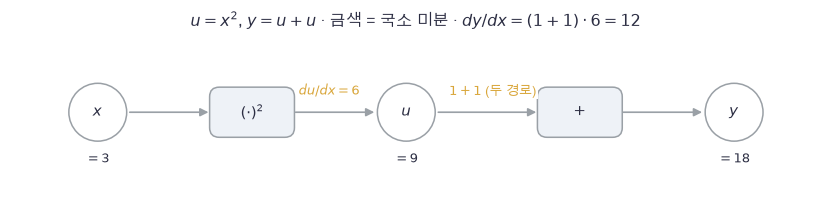

In [3]:
plot_shared_path(path_x, path_u, path_y, path_du_dx, path_dy_du_each, path_dx)

🔍 **확인** · $y$에서 $u$로 돌아오는 기울기는 두 화살표 각각 1이라 합이 2입니다. $u$에서 $x$로는 국소 미분 6을 곱해 12입니다. 자동미분은 이 두 가지, 즉 **국소 미분을 곱하고 같은 노드로 오는 기여를 더하는 것**만 반복합니다.

### 🔍 작은 Jacobian으로 VJP 확인하기

$y=(x_0x_1,\ x_0+x_1^2)$의 $2\times2$ Jacobian을 손으로 쓰고, 출력 쪽 기울기 $g$와 곱해 입력 쪽 기울기를 얻습니다.

In [4]:
# 작은 Jacobian을 실제로 써서 VJP와 내적 목적의 미분을 비교합니다.
x_hand = np.array([2., 3.])                                     # (2,): 입력
J_hand = np.array([[x_hand[1], x_hand[0]], [1., 2*x_hand[1]]])  # (2, 2): y=(x0*x1, x0+x1**2)의 Jacobian ∂y_i/∂x_j
g_hand = np.array([.5, -2.])                                    # (2,): 출력 쪽 기울기
vjp_hand = J_hand.T @ g_hand                                    # (2,): 입력 쪽 기울기 Jᵀg
np.testing.assert_allclose(vjp_hand, [-.5, -11.])               # 검산: 손계산 [0.5·3 − 2·1, 0.5·2 − 2·6]
print('J.T @ g:', vjp_hand)

J.T @ g: [ -0.5 -11. ]


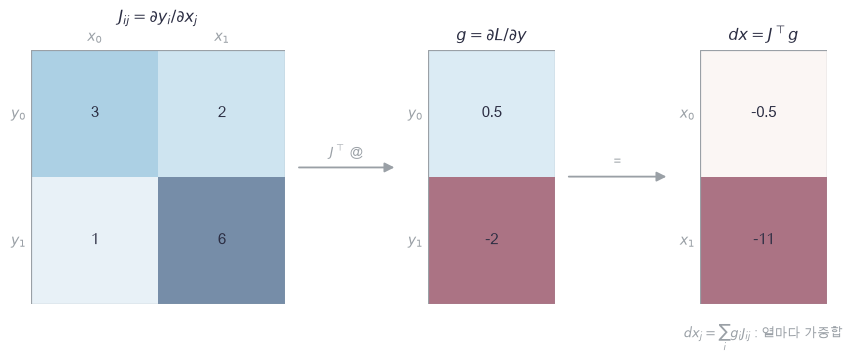

In [5]:
plot_vjp(J_hand, g_hand, vjp_hand, ["$y_0$", "$y_1$"], ["$x_0$", "$x_1$"])

🔍 **확인** · $dx_0=g_0J_{00}+g_1J_{10}=0.5\cdot3+(-2)\cdot1=-0.5$처럼 $J$의 **열**마다 $g$로 가중합합니다. $J^\top g$가 그 계산입니다. 아래 엔진의 각 연산은 이 곱을 $J$ 없이 바로 씁니다.

### ✏️ 연습 1 · Jᵀg, VJP를 한 줄로

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

Jacobian `J` `(M, D)`와 출력 쪽 기울기 `g` `(M,)`에서 입력 쪽 기울기 `dx` `(D,)`를 내는 한 줄을 채우세요. $J$의 열마다 $g$로 가중합하는 것이 $J^\top g$입니다. 검사는 1절 손계산과, 같은 $u$를 두 곳에 쓰는 것이 $u$를 두 자리로 복사하는 연산(Jacobian `[[1], [1]]`)이라고 볼 때 두 자리의 기여가 더해져 $du=2$가 되는지도 봅니다.

In [6]:
def exercise_vjp(J, g):
    """연습 1: VJP. J: (M, D) Jacobian (행 i = 출력 y_i, 열 j = 입력 x_j), g: (M,) 출력 쪽 기울기 → dx: (D,) 입력 쪽 기울기."""
    assert J.shape[0] == g.shape[0], "J의 행 수 M과 g의 길이 M이 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: J의 열마다 g로 가중합한 입력 쪽 기울기 dx (모양 (D,)). dx_j = Σ_i g_i J_ij
    ### 힌트: 1절 Jacobian 셀의 vjp_hand 한 줄입니다. 전치를 곱하면 열마다의 가중합이 됩니다.
    raise NotImplementedError
    return dx

In [7]:
def check_vjp(candidate):
    """1절 손계산 둘과 복사 연산 하나로 후보 함수를 검사합니다. 통과하면 메시지를 출력합니다."""
    example_J = np.array([[3., 2.], [1., 6.]])                  # (2, 2): 1절 y = (x0·x1, x0 + x1²)의 Jacobian (x = (2, 3))
    example_g = np.array([.5, -2.])                             # (2,)
    actual = candidate(example_J, example_g)
    assert actual.shape == (2,), f"입력 쪽 기울기의 모양은 (D,) = (2,)여야 하는데 {actual.shape}입니다"
    np.testing.assert_allclose(actual, [-.5, -11.])             # 검산: 1절 손계산 [0.5·3 − 2·1, 0.5·2 − 2·6]
    tall_J = np.array([[1., 0.], [2., 1.], [0., 3.]])           # (3, 2): 출력 3개, 입력 2개
    np.testing.assert_allclose(candidate(tall_J, np.array([1., -1., 2.])), [-1., 5.])   # 검산: 열 0은 1·1 + 2·(−1) + 0·2, 열 1은 0 − 1 + 3·2
    copy_J = np.array([[1.], [1.]])                              # (2, 1): u를 두 자리로 복사하는 연산 u → (u, u)의 Jacobian
    np.testing.assert_allclose(candidate(copy_J, np.ones(2)) * 6., [12.])   # 검산: 두 자리에서 온 g = [1, 1]을 모으면 du = 2, 국소 미분 du/dx = 6을 곱해 1절의 12
    print("VJP Jᵀg: 손계산과 일치합니다.")

run_check(check_vjp, exercise_vjp, hint="dx = J.T @ g")

☐ exercise_vjp: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dx = J.T @ g


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dx = J.T @ g
```

</details>

## 🔑 2. broadcasting의 역방향은 합치기입니다

**이 절에서 가져갈 것:** 작은 배열을 복사해 큰 배열과 계산했으면, 역방향에서는 복사된 자리로 온 기울기를 **모두 더해** 원래 모양으로 돌려줍니다. 앞에 추가된 축은 합하고, 길이 1이던 축은 `keepdims=True`로 합합니다.

$Y=X+b$에서 $b$ $(D,)$는 $N$개 행에 똑같이 더해졌습니다. $b_j$가 $N$번 쓰였으니 $b_j$의 기울기는 그 $N$개 자리의 기울기를 더한 것입니다. 1절의 "같은 값이 여러 경로에 쓰이면 더한다"와 같은 일입니다.

> **용어** · **broadcasting 역방향(`sum_to_shape`)**: 기울기 $(N,D)$를 원래 모양 $(D,)$나 $(N,1)$로 줄이는 합. 코드에서는 앞 축은 `sum(axis=0)`, 길이 1 축은 `sum(axis=k, keepdims=True)`.

$Y=X+b$에서 $X:(N,D)$, $b:(D,)$이면 $b_j$가 $N$번 쓰입니다.
따라서 $db_j=\sum_n dY_{nj}$입니다. `(N,1)`을 `(N,D)`로 확장했다면 열을 합해야 합니다.
앞에 추가된 축을 합하고, 원래 길이가 1이었던 축을 길이 1로 남기며 합하면 원래 shape의 기울기를 얻습니다.
`keepdims=True`는 합한 축의 길이를 1로 유지합니다.

> **코드**
>
> - `np.broadcast_to(bc_b, (2, 3))`: forward에서 일어나는 복사를 눈에 보이게 만든 것. 실제 `X + b`는 복사 없이 같은 결과를 냅니다.
> - `while g.ndim > len(original_shape): g = g.sum(axis=0)`: 앞에 추가된 축이 남아 있는 동안 첫 축을 합칩니다.
> - `for axis, size in enumerate(original_shape)`: 원래 모양의 축 번호와 길이를 함께 돌며, 길이가 1이던 축은 `keepdims=True`로 합칩니다.
> - `g.reshape(original_shape)`: 모양 `()`(스칼라)까지 포함해 원래 모양으로 되돌립니다.

In [8]:
bc_b = np.array([3., 4., 5.])                                         # (D=3,): 편향 b
bc_expanded = np.broadcast_to(bc_b, (2, 3))                           # (N=2, D): forward에서 행마다 복사된 모습
bc_upstream = np.arange(1., 7.).reshape(2, 3)                         # (2, 3): 뒤에서 온 기울기 dY
bc_db = bc_upstream.sum(axis=0)                                       # (3,): 복사한 자리를 더함 = db
print("복사\n", bc_expanded, "\ndY\n", bc_upstream, "\ndb =", bc_db)

복사
 [[3. 4. 5.]
 [3. 4. 5.]] 
dY
 [[1. 2. 3.]
 [4. 5. 6.]] 
db = [5. 7. 9.]


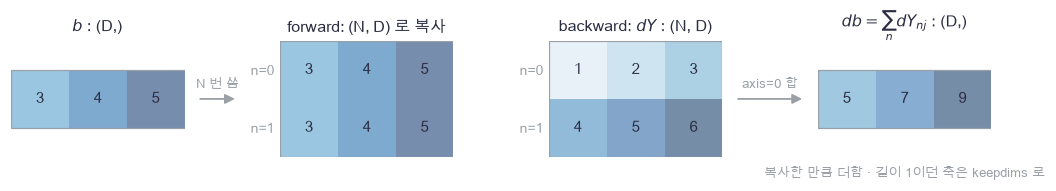

In [9]:
plot_broadcast_backward(bc_b, bc_expanded, bc_upstream, bc_db)

🔍 **확인** · $b$의 첫 원소 3은 두 행에 모두 쓰였으므로 그 자리의 기울기 1과 4를 더한 5가 $db_0$입니다. 아래 구현은 일반 모양에 대해 앞 축과 길이 1 축을 차례로 합칩니다.

In [10]:
def sum_to_shape(gradient, original_shape):
    """broadcasting의 역방향: 기울기를 원래 모양으로 합칩니다. 앞에 추가된 축은 합하고, 길이 1이던 축은 keepdims로 합합니다.
    gradient: broadcasting된 모양, original_shape: 원래 모양 → original_shape의 배열."""
    g = np.asarray(gradient)
    while g.ndim > len(original_shape):                     # 1. 앞에 추가된 축을 합침
        g = g.sum(axis=0)
    for axis, size in enumerate(original_shape):            # 2. 길이 1이던 축을 길이 1로 남기며 합침
        if size == 1:
            g = g.sum(axis=axis, keepdims=True)
    return g.reshape(original_shape)

In [11]:
# 쓰는 것: bc_upstream, bc_db (2절 그림 셀)
upstream = np.arange(1., 7.).reshape(2, 3)                  # (2, 3): 뒤에서 온 기울기
np.testing.assert_allclose(sum_to_shape(upstream, (3,)), [5., 7., 9.])       # 검산: (D,)로 → 열별 합
np.testing.assert_allclose(sum_to_shape(upstream, (2, 1)), [[6.], [15.]])    # 검산: (N, 1)로 → 행별 합
np.testing.assert_allclose(sum_to_shape(upstream, ()), 21.)                  # 검산: 스칼라로 → 전체 합
print('broadcast 역방향: 열별 / 행별 / 전체 합 검산')
np.testing.assert_allclose(sum_to_shape(bc_upstream, (3,)), bc_db)           # 검산: 위 그림의 db와 같음

broadcast 역방향: 열별 / 행별 / 전체 합 검산


🔍 **확인** · 열별 합 `[5, 7, 9]`, 행별 합 `[[6], [15]]`, 전체 합 21이 각각 $(D,)$, $(N,1)$, $()$ 모양의 기울기입니다.

### ✏️ 연습 2 · 스칼라와 (1, D)로 돌아가기

뒤에서 온 기울기 `G` `(N, D)`에서, 스칼라 `c`를 전체에 더했을 때의 기울기 `dc` `()`와 행 하나 `(1, D)`를 `N`번 복사해 더했을 때의 기울기 `drow` `(1, D)`를 만드는 두 줄을 채우세요. 2절 검산 셀의 `(D,)`·`(N, 1)`에 이어, 축이 모두 사라지는 `()`와 축 0이 길이 1로 남는 `(1, D)`입니다.

In [12]:
def exercise_sum_back(G):
    """연습 2: broadcasting 역방향, 스칼라와 (1, D)의 경우. G: (N, D) 뒤에서 온 기울기 → (dc: 스칼라 (), drow: (1, D))."""
    assert G.ndim == 2, "G는 (N, D) 2차원이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 스칼라 c를 (N, D) 전체에 더했을 때의 기울기 dc (모든 원소의 합, 모양 ())와, (1, D) 행 하나를 N번 복사했을 때의 기울기 drow (앞 축을 길이 1로 남기며 합한 (1, D))
    ### 힌트: 2절 sum_to_shape의 두 규칙입니다. 스칼라 ()는 두 축이 모두 앞에 추가된 축이라 전부 합하고, (1, D)는 길이 1이던 축 0을 keepdims=True로 합합니다.
    raise NotImplementedError
    return dc, drow

In [13]:
def check_sum_back(candidate):
    """2절 손계산 (2, 3) 예제 하나와 본문 sum_to_shape로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: sum_to_shape (2절)
    example_G = np.arange(1., 7.).reshape(2, 3)                  # (2, 3): 2절 그림의 dY = [[1, 2, 3], [4, 5, 6]]
    dc, drow = candidate(example_G)
    assert np.shape(dc) == (), f"스칼라의 기울기는 모양 ()여야 하는데 {np.shape(dc)}입니다"
    assert drow.shape == (1, 3), f"(1, D) 행의 기울기는 (1, 3)이어야 하는데 {drow.shape}입니다"
    np.testing.assert_allclose(dc, 21.)                          # 검산: 여섯 자리에 모두 쓰였으니 1 + 2 + … + 6 = 21
    np.testing.assert_allclose(drow, [[5., 7., 9.]])             # 검산: 두 행에 복사됐으니 열별 합 [1+4, 2+5, 3+6], 축 0은 길이 1로 남김
    other_G = np.random.default_rng(134).normal(size=(4, 5))     # (4, 5)
    dc_o, drow_o = candidate(other_G)
    np.testing.assert_allclose(dc_o, sum_to_shape(other_G, ()))          # 검산: 본문 sum_to_shape의 () 경우와 같음
    np.testing.assert_allclose(drow_o, sum_to_shape(other_G, (1, 5)))    # 검산: (1, D) 경우도 같음
    print("스칼라와 (1, D)의 기울기: 손계산·sum_to_shape와 일치합니다.")

run_check(check_sum_back, exercise_sum_back, hint="dc = G.sum(), drow = G.sum(axis=0, keepdims=True)")

☐ exercise_sum_back: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dc = G.sum(), drow = G.sum(axis=0, keepdims=True)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dc = G.sum()
drow = G.sum(axis=0, keepdims=True)
```

</details>

## 🔑 3. Node: 값·부모·국소 backward 보관하기

**이 절에서 가져갈 것:** `Node`는 값(`data`), 기울기(`grad`), 입력 노드들(`parents`), 그리고 뒤에서 온 기울기를 부모에게 더해 주는 함수(`pullback`) 넷을 들고 있습니다. backward는 부모를 먼저 방문하는 위상 순서를 만든 뒤 거꾸로 돌며 각 pullback을 한 번씩 부릅니다.

> **용어**
>
> - **pullback**: 출력 쪽 기울기 $g$를 받아 각 부모의 `grad`에 $J^\top g$를 **더하는** 함수. 연산마다 하나씩 만들어 출력 Node에 붙입니다.
> - **위상 순서(topological order)**: 모든 입력이 그것을 쓰는 연산보다 앞에 오는 순서. 뒤집으면 "출력부터 입력으로"가 되어 backward 순서가 됩니다.
> - **closure**: 함수 안에서 만든 함수가 바깥 변수(부모 노드, 순전파 값)를 기억하는 것. 아래 `back` 함수가 그렇게 부모를 기억합니다.

`Node.data`는 순전파 값, `Node.grad`는 그 값에 대한 손실의 기울기입니다. `parents`는 입력 Node들의 tuple이며, `pullback`은 뒤에서 온 기울기를 부모에게 더하는 함수입니다.
클래스의 `__add__`, `__mul__`, `__matmul__`은 Python이 `+`, `*`, `@`를 실행할 때 부르는 메서드입니다. 아래에서 정의할 연산 함수로 연결합니다.

**위상 순서**는 각 입력이 그 입력을 사용하는 연산보다 먼저 오는 순서입니다.
부모를 먼저 방문하고 자신을 목록에 추가한 뒤 목록을 뒤집으면 역전파 순서가 됩니다.
같은 Node는 한 번만 목록에 넣되, 모든 사용 경로의 기울기를 `+=`로 모읍니다.

이 교육용 엔진은 매 `backward` 호출마다 도달 가능한 Node의 기울기를 0으로 만들고 새로 계산합니다.
파라미터 갱신은 그 그래프의 backward가 끝난 뒤 수행하며, 다음 스텝에서 순전파 그래프를 새로 만듭니다.

아래는 4절에서 쓸 MLP 손실의 계산 그래프와 위상 순서입니다.

> **코드**
>
> - `class Node:` 와 `def __init__(self, …)`: 값 하나를 감싸는 새 자료형과, 만들 때 실행되는 초기화. `self`가 그 Node 자신입니다. `Node(3.)`처럼 부릅니다.
> - `np.array(data, dtype=float, copy=True)`: 어떤 숫자·배열이 와도 실수 배열의 복사본으로. `tuple(parents)`: 부모 목록을 바꿀 수 없는 튜플로.
> - `def visit(node):` 안에서 `visit(parent)`를 다시 부르는 **재귀**: 부모의 부모까지 먼저 방문합니다. `visited = set()`과 `visited.add(node)`는 같은 Node를 두 번 넣지 않기 위한 집합입니다.
> - `reversed(order)`: 목록을 거꾸로. 부모가 먼저인 순서를 뒤집으면 출력이 먼저입니다.
> - `def __add__(self, other)`: `a + b`를 쓰면 Python이 `a.__add__(b)`를 부릅니다. `__radd__`는 `3 + a`처럼 왼쪽이 숫자일 때, `__neg__`는 `-a`, `__matmul__`은 `a @ b`입니다.
> - `isinstance(value, Node)`: 이미 Node이면 그대로, 아니면 새 Node로 감쌉니다.

In [14]:
mlp_order = ["X", "W1", "op:mm1", "b1", "op:add1", "op:tanh", "W2", "op:mm2", "b2", "op:add2", "Y", "op:sub", "op:sq", "op:mean", "L"]   # 도식용: 4절 MLP 손실 그래프의 위상 순서
print("위상 순서 (부모가 먼저):", " → ".join(mlp_order))
print("backward 순서:", " → ".join(reversed(mlp_order)))

위상 순서 (부모가 먼저): X → W1 → op:mm1 → b1 → op:add1 → op:tanh → W2 → op:mm2 → b2 → op:add2 → Y → op:sub → op:sq → op:mean → L
backward 순서: L → op:mean → op:sq → op:sub → Y → op:add2 → b2 → op:mm2 → W2 → op:tanh → op:add1 → b1 → op:mm1 → W1 → X


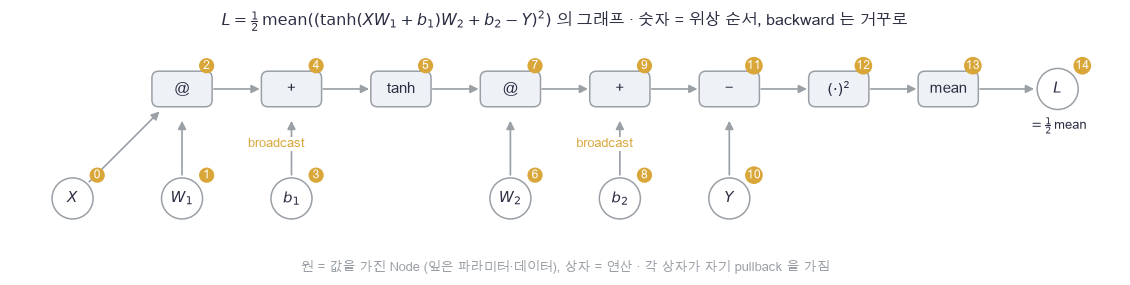

In [15]:
plot_mlp_graph(mlp_order)

🔍 **확인** · 잎(입력·파라미터·정답)은 부모가 없고, 연산 상자는 부모의 값으로 자기 값을 만듭니다. 금색 번호가 위상 순서이며 어떤 상자도 자기 부모보다 앞에 오지 않습니다. backward는 $L$부터 이 번호를 거꾸로 돌며 상자마다 pullback을 부릅니다.
아래 구현이 `Node` 클래스입니다. `backward`가 방문·순서·초기화·pullback 호출을 모두 담당합니다.

In [16]:
class Node:
    """계산 그래프의 노드: 값(data), 기울기(grad), 입력 노드들(parents), 뒤에서 온 기울기를 부모에게 더해 주는 함수(pullback).
    +, *, @, tanh, sum, mean을 쓰면 아래 연산 함수(add, multiply, …)가 새 Node를 만들어 그래프가 자랍니다."""

    def __init__(self, data, parents=(), pullback=None):
        """값을 실수 배열로 복사해 보관하고, 같은 모양의 0 기울기를 준비합니다. 잎(입력·파라미터)은 parents가 비어 있습니다."""
        self.data = np.array(data, dtype=float, copy=True)
        self.grad = np.zeros_like(self.data)
        self.parents = tuple(parents)
        self.pullback = pullback

    def backward(self, seed=None):
        """이 노드부터 역전파: 1. 위상 순서 만들기 → 2. seed 확인 → 3. 도달한 노드의 grad를 0으로 → 4. 출력부터 pullback 호출.
        seed: 출력 쪽 시작 기울기 (스칼라 출력이면 생략, 벡터 출력이면 같은 모양의 배열)."""
        # 1. 위상 순서: 부모를 먼저 방문하고 자신을 뒤에 넣음 (같은 노드는 한 번만)
        order, visited = [], set()
        def visit(node):
            """node의 부모들을 먼저 방문한 뒤 node를 order에 넣습니다 (재귀)."""
            if node in visited:
                return
            visited.add(node)
            for parent in node.parents:
                visit(parent)
            order.append(node)
        visit(self)
        # 2. seed: 스칼라 출력은 dL/dL = 1, 벡터 출력은 목적을 정하는 가중치
        if seed is None:
            if self.data.shape != ():
                raise ValueError('벡터 출력에는 같은 shape의 seed를 전달합니다.')
            seed = np.ones_like(self.data)
        seed = np.asarray(seed, dtype=float)
        if seed.shape != self.data.shape:
            raise ValueError('seed와 출력의 shape를 맞춥니다.')
        # 3. 도달 가능한 모든 노드의 기울기를 0으로 (매 backward마다 새로 계산)
        for node in order:
            node.grad = np.zeros_like(node.data)
        self.grad = seed.copy()
        # 4. 출력부터 입력으로: 노드마다 pullback을 한 번씩 불러 부모의 grad에 더함
        for node in reversed(order):
            if node.pullback is not None:
                node.pullback(node.grad)

    # 연산자 연결: a + b, a * b, a @ b 등을 쓰면 아래 셀의 연산 함수를 부릅니다
    def __add__(self, other):
        """a + b"""
        return add(self, other)

    def __radd__(self, other):
        """3 + a (왼쪽이 숫자)"""
        return add(other, self)

    def __mul__(self, other):
        """a * b"""
        return multiply(self, other)

    def __rmul__(self, other):
        """3 * a"""
        return multiply(other, self)

    def __neg__(self):
        """-a = a * (−1)"""
        return multiply(self, -1.)

    def __sub__(self, other):
        """a − b = a + (−b)"""
        return add(self, -as_node(other))

    def __matmul__(self, other):
        """a @ b"""
        return matmul(self, other)

    def tanh(self):
        """a.tanh()"""
        return tanh(self)

    def sum(self):
        """a.sum(): 모든 원소의 합 (스칼라 Node)"""
        return total_sum(self)

    def mean(self):
        """a.mean(): 합을 원소 수로 나눔"""
        return total_sum(self) * (1. / self.data.size)

In [17]:
def as_node(value):
    """이미 Node이면 그대로, 숫자·배열이면 새 잎 Node로 감쌉니다."""
    return value if isinstance(value, Node) else Node(value)

### 🔑 국소 규칙을 코드로 넣기

**이 절에서 가져갈 것:** 연산마다 pullback 한 줄씩입니다. 덧셈은 $g$를 그대로, 곱셈은 상대 입력을 곱해서, 행렬곱은 전치를 곱해서, tanh는 $(1-y^2)$를 곱해서 부모에게 더합니다. broadcasting이 있었으면 `sum_to_shape`로 줄입니다.

$Y=A+B$: $dA=G$, $dB=G$, 각 원래 shape로 합칩니다.

$Y=A\odot B$: $dA=G\odot B$, $dB=G\odot A$, broadcasting 축을 합칩니다.

$Y=AB$: $dA=GB^T$, $dB=A^TG$. 이 엔진의 행렬곱은 **2차원 행렬 둘**을 사용합니다.

$Y=\tanh A$: $dA=G\odot(1-Y^2)$.

$Y=\sum A$: 입력 모든 원소에 스칼라 $G$를 전달합니다. `mean`은 전체 원소 수로 나눈 `sum`입니다.
내부 `back` 함수가 부모와 순전파 값을 기억하는 방식은 Python의 closure입니다.

아래는 `(row * column + column).sum()`의 그래프입니다. `row`는 $(2,1)$, `column`은 $(3,)$이라 곱셈에서 양쪽이 broadcasting되고, `column`은 두 경로에 쓰입니다.

> **코드**
>
> - `def back(g): …` 뒤 `return Node(value, (a, b), back)`: 연산 함수 안에서 pullback 함수를 만들어 새 Node에 붙입니다. `back`은 바깥의 `a`, `b`, `value`를 기억하는 closure입니다.
> - `a.grad += …`: 부모의 기울기에 **더합니다**. 같은 부모가 여러 연산에 쓰였으면 각 연산의 back이 차례로 더합니다.
> - `np.ones_like(a.data) * g`: 스칼라 g를 입력 모양으로 펼칩니다. sum의 국소 미분은 모든 원소에 1입니다.

In [18]:
rule_row = np.array([[1.], [2.]])                                          # (2, 1)
rule_column = np.array([3., 4., 5.])                                        # (3,)
rule_prod = rule_row * rule_column                                          # (2, 3): 양쪽 broadcasting
rule_total = (rule_prod + rule_column).sum()                                # 스칼라
rule_G = np.ones((2, 3))                                                    # (2, 3): sum 의 pullback: 모든 원소에 1
rule_row_grad = (rule_G * rule_column).sum(axis=1, keepdims=True)           # (2, 1): 곱셈 g ⊙ column 을 row 모양으로 합침
rule_column_grad = (rule_G * rule_row).sum(axis=0) + rule_G.sum(axis=0)     # (3,): 곱셈 경로 + 덧셈 경로를 더함
print("합 =", rule_total, "· row.grad =", rule_row_grad.ravel(), "· column.grad =", rule_column_grad)

합 = 60.0 · row.grad = [12. 12.] · column.grad = [5. 5. 5.]


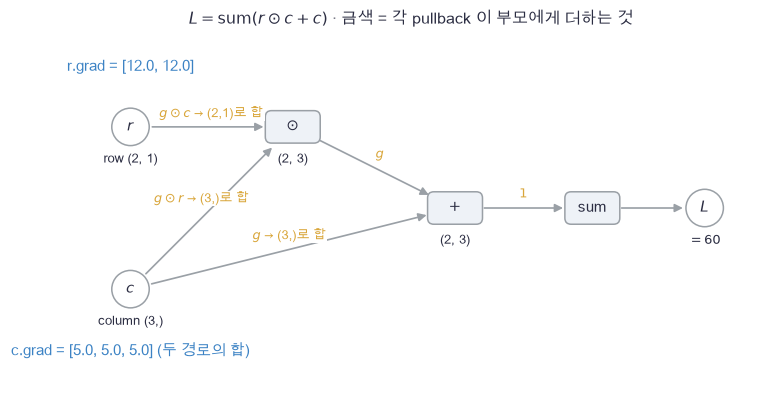

In [19]:
plot_local_rules(rule_row, rule_column, rule_row_grad, rule_column_grad)

🔍 **확인** · `column`은 곱셈과 덧셈 두 곳에 쓰였으므로 두 경로의 기여 $[3,3,3]+[2,2,2]$를 더해 $[5,5,5]$입니다. `row`는 곱셈에서 `column`을 곱한 기울기를 열 방향으로 합쳐 $[12,12]$입니다. 아래 구현의 각 `back`이 이 한 줄들이고, 검산에서 같은 값이 나오는지 봅니다.

In [20]:
def add(a, b):
    """Y = A + B. pullback: dA = G, dB = G를 각각 원래 모양으로 합침."""
    # 쓰는 것: sum_to_shape (2절) · Node, as_node (3절)
    a, b = as_node(a), as_node(b)
    def back(g):
        """덧셈의 국소 미분은 1: g를 그대로 부모에게 (broadcasting은 합쳐서)."""
        a.grad += sum_to_shape(g, a.data.shape)
        b.grad += sum_to_shape(g, b.data.shape)
    return Node(a.data + b.data, (a, b), back)


def multiply(a, b):
    """Y = A ⊙ B. pullback: dA = G ⊙ B, dB = G ⊙ A를 각각 원래 모양으로 합침."""
    a, b = as_node(a), as_node(b)
    def back(g):
        """곱셈의 국소 미분은 상대 입력."""
        a.grad += sum_to_shape(g * b.data, a.data.shape)
        b.grad += sum_to_shape(g * a.data, b.data.shape)
    return Node(a.data * b.data, (a, b), back)

In [21]:
# 쓰는 것: Node, as_node (3절)
def matmul(a, b):
    """Y = AB (2차원 행렬 둘). pullback: dA = GBᵀ, dB = AᵀG (01번 4절의 affine backward)."""
    a, b = as_node(a), as_node(b)
    if a.data.ndim != 2 or b.data.ndim != 2:
        raise ValueError('이 matmul의 입력은 2차원 행렬 두 개입니다.')
    def back(g):
        """행렬곱의 국소 미분: 상대 입력의 전치를 곱함."""
        a.grad += g @ b.data.T
        b.grad += a.data.T @ g
    return Node(a.data @ b.data, (a, b), back)


def tanh(a):
    """Y = tanh A. pullback: dA = G ⊙ (1 − Y²)."""
    a = as_node(a)
    value = np.tanh(a.data)
    def back(g):
        """tanh의 국소 미분 1 − Y² (순전파 값 value를 기억해 둠)."""
        a.grad += g * (1 - value**2)
    return Node(value, (a,), back)


def total_sum(a):
    """Y = Σ A (스칼라). pullback: 모든 원소에 G를 전달."""
    a = as_node(a)
    def back(g):
        """합의 국소 미분은 모든 원소에 1."""
        a.grad += np.ones_like(a.data) * g
    return Node(a.data.sum(), (a,), back)

In [22]:
# 쓰는 것: Node (3절) · rule_row_grad, rule_column_grad (국소 규칙 그림 셀)
x = Node(3.)
u = x * x                                                   # 같은 x가 곱셈의 양쪽 부모
y = u + u                                                   # 같은 u가 두 경로
y.backward()
np.testing.assert_allclose([u.data, y.data, x.grad], [9., 18., 12.])   # 검산: 1절 손계산 (공유 경로의 합)
y.backward()
np.testing.assert_allclose(x.grad, 12.)                     # 검산: 두 번 backward해도 같음 (초기화)

v = Node(np.array([2., 3.]))
f = v * v + v                                               # (2,): 벡터 출력
f.backward(np.array([.5, -2.]))                             # 벡터 seed g
np.testing.assert_allclose(v.grad, [2.5, -14.])             # 검산: g ⊙ (2v + 1) = [0.5·5, −2·7]

row = Node(np.array([[1.], [2.]]))
column = Node(np.array([3., 4., 5.]))
broadcast_output = (row * column + column).sum()            # 양쪽 broadcasting + 공유 경로
broadcast_output.backward()
np.testing.assert_allclose(row.grad, [[12.], [12.]])        # 검산: 국소 규칙 손계산
np.testing.assert_allclose(column.grad, [5., 5., 5.])       # 검산: 두 경로의 합 [3,3,3] + [2,2,2]
print('공유 경로·재계산·벡터 seed·양쪽 broadcasting 통과')
np.testing.assert_allclose(row.grad, rule_row_grad)         # 검산: 위 그림과 같은 값
np.testing.assert_allclose(column.grad, rule_column_grad)   # 검산: column도 같음

공유 경로·재계산·벡터 seed·양쪽 broadcasting 통과


🔍 **확인** · 공유 경로($x\cdot x$의 12), 두 번 backward해도 같은 값(초기화), 벡터 seed, 양쪽 broadcasting이 모두 손계산과 맞습니다.
같은 $x$가 곱셈의 양쪽 부모에 있어도 두 항을 더해야 합니다. 그래프를 방문하는 횟수와 기울기 기여의 수는 서로 다른 개념입니다.

### ✏️ 연습 3-1 · 부모 먼저, 나는 나중에

출력 `Node`에서 시작해 부모를 먼저 방문하고 자신을 목록 끝에 넣는 재귀 `visit`의 빈 곳을 채우세요. 방문 표시와 재귀의 틀은 써 두었습니다. 결과 `order`는 부모가 항상 자식보다 앞에 오고 공유된 Node는 한 번만 들어가며, 검사는 이 순서를 뒤집어 pullback을 한 번씩 돌렸을 때 1절 손계산 12가 나오는지도 봅니다.

In [23]:
def exercise_topological_order(output):
    """연습 3-1: 출력 Node부터 부모를 먼저 방문하는 위상 순서. output: Node → order: Node 목록 (부모가 먼저, output이 마지막, 같은 Node는 한 번)."""
    order, visited = [], set()
    def visit(node):
        """node의 부모들을 먼저 방문한 뒤 node를 order에 넣습니다 (재귀)."""
        if node in visited:
            return
        visited.add(node)
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: node.parents의 부모마다 visit을 먼저 부르고, 그다음에 node 자신을 order 끝에 넣습니다
        ### 힌트: 3절 Node.backward의 1단계 visit입니다. 순서를 바꾸면 자식이 부모보다 앞에 옵니다.
        raise NotImplementedError
    visit(output)
    return order

In [24]:
def check_topological_order(candidate):
    """1절 손계산 그래프와 국소 규칙 그래프로 순서를 검사하고, 그 순서를 뒤집어 pullback을 돌려 12가 나오는지 봅니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: Node (3절)
    x = Node(3.)
    u = x * x                                                    # 같은 x가 양쪽 부모
    y = u + u                                                    # 같은 u가 두 경로
    order = candidate(y)
    assert order == [x, u, y], "순서는 [x, u, y]여야 합니다: 부모가 먼저이고 공유된 Node는 한 번만 들어갑니다"
    for node in order:                                           # Node.backward의 3단계: 도달한 노드의 grad를 0으로
        node.grad = np.zeros_like(node.data)
    y.grad = np.ones(())                                         # seed dL/dL = 1
    for node in reversed(order):                                 # 4단계: 뒤집은 순서로 pullback을 한 번씩
        if node.pullback is not None:
            node.pullback(node.grad)
    np.testing.assert_allclose(x.grad, 12.)                      # 검산: 1절 손계산 (1 + 1)·6 = 12
    row, column = Node(np.array([[1.], [2.]])), Node(np.array([3., 4., 5.]))
    total = (row * column + column).sum()                        # 3절 국소 규칙 그림의 그래프
    order_2 = candidate(total)
    assert len(order_2) == 5, f"Node 5개(row, column, 곱, 합, sum)가 한 번씩이어야 하는데 {len(order_2)}개입니다"
    assert len(set(order_2)) == 5, "같은 Node가 두 번 들어가면 안 됩니다"
    for child in order_2:                                        # 자식마다 부모가 앞에 있는지
        for parent in child.parents:
            assert order_2.index(parent) < order_2.index(child), "모든 부모가 자식보다 앞에 와야 합니다"
    print("위상 순서: 부모가 먼저이고, 뒤집어 돌리면 손계산 12가 나옵니다.")

run_check(check_topological_order, exercise_topological_order, hint="for parent in node.parents: visit(parent) · 그다음 order.append(node)")

☐ exercise_topological_order: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: for parent in node.parents: visit(parent) · 그다음 order.append(node)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
for parent in node.parents:
    visit(parent)
order.append(node)
```

</details>

### ✏️ 연습 3-2 · 덧셈 노드의 pullback

값과 부모는 써 두었습니다. `back` 안에서 덧셈의 국소 미분 1을 적용해 `g`를 두 부모의 `grad`에 **더하는** 두 줄을 채우세요. `(2, 3) + (3,)`처럼 broadcasting이 있었으면 `sum_to_shape`로 원래 모양으로 합칩니다. 이 소절의 네 규칙 중 곱셈·행렬곱·tanh와 달리 덧셈은 곱할 국소 미분이 없어, 합치기만 남습니다.

In [25]:
def exercise_add_node(a, b):
    """연습 3-2: 덧셈 연산 노드. a, b: Node 또는 배열 (broadcasting 가능) → 값 a + b와 pullback을 가진 새 Node."""
    a, b = as_node(a), as_node(b)
    def back(g):
        """pullback: 덧셈의 국소 미분은 1이라 g를 그대로 두 부모에게 더하되, broadcasting된 축은 원래 모양으로 합칩니다."""
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: a.grad와 b.grad에 각각 g를 원래 모양(a.data.shape, b.data.shape)으로 합쳐 더합니다 (= 이 아니라 +=)
        ### 힌트: 3절 add의 back 두 줄입니다. 합치는 함수는 2절의 sum_to_shape입니다.
        raise NotImplementedError
    return Node(a.data + b.data, (a, b), back)

In [26]:
def check_add_node(candidate):
    """국소 규칙 그림의 덧셈 경로, 스칼라 부모, 같은 잎을 두 번 쓴 누적, 본문 add와의 비교로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: Node, add (3절)
    big, column = Node(np.zeros((2, 3))), Node(np.array([3., 4., 5.]))
    out = candidate(big, column)
    assert isinstance(out, Node), "결과는 Node여야 합니다"
    assert out.parents == (big, column), "부모는 (a, b) 두 노드여야 합니다"
    out.backward(np.arange(1., 7.).reshape(2, 3))               # g = [[1, 2, 3], [4, 5, 6]]
    np.testing.assert_allclose(big.grad, np.arange(1., 7.).reshape(2, 3))   # 검산: (2, 3) 부모에게는 g 그대로
    np.testing.assert_allclose(column.grad, [5., 7., 9.])       # 검산: (3,) 부모는 두 행에 복사됐으니 열별 합
    scalar = Node(1.)
    candidate(big, scalar).backward(np.ones((2, 3)))
    np.testing.assert_allclose(scalar.grad, 6.)                  # 검산: 스칼라는 여섯 자리에 쓰였으니 1이 여섯 번 = 6
    shared = Node(np.array([0.3, 0.7]))
    candidate(shared, shared).backward(np.ones(2))
    np.testing.assert_allclose(shared.grad, [2., 2.])            # 검산: 양쪽 부모가 같은 잎이면 더해짐 (+=)
    rng_c = np.random.default_rng(135)
    a_c, b_c, g_c = rng_c.normal(size=(3, 1)), rng_c.normal(size=(3, 4)), rng_c.normal(size=(3, 4))
    mine_a, mine_b, ref_a, ref_b = Node(a_c), Node(b_c), Node(a_c), Node(b_c)
    candidate(mine_a, mine_b).backward(g_c)
    add(ref_a, ref_b).backward(g_c)                              # 본문 add로 같은 계산
    np.testing.assert_allclose(mine_a.grad, ref_a.grad)          # 검산: (3, 1) 쪽도 본문 add와 같음
    np.testing.assert_allclose(mine_b.grad, ref_b.grad)          # 검산: (3, 4) 쪽도 같음
    print("덧셈 노드: 손계산·본문 add와 일치합니다.")

run_check(check_add_node, exercise_add_node, hint="a.grad += sum_to_shape(g, a.data.shape); b.grad += sum_to_shape(g, b.data.shape)")

☐ exercise_add_node: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: a.grad += sum_to_shape(g, a.data.shape); b.grad += sum_to_shape(g, b.data.shape)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
a.grad += sum_to_shape(g, a.data.shape)
b.grad += sum_to_shape(g, b.data.shape)
```

</details>

## 🔍 4. 동일한 MLP를 네 가지 미분으로 검산하기

$H=\tanh(XW_1+b_1)$, $\hat Y=HW_2+b_2$,
$L=\tfrac1{2NK}\sum_{n,k}(\hat Y_{nk}-Y_{nk})^2$를 사용합니다.
$X:(N,D)$, $W_1:(D,H)$, $b_1:(H,)$, $W_2:(H,K)$, $b_2:(K,)$입니다.
전체 원소 평균이므로 출력 쪽 기울기는 $(\hat Y-Y)/(NK)$입니다.

같은 가중치에서 (1) 03번처럼 손으로 쓴 backward, (2) 이 엔진, (3) PyTorch, (4) 중심차분을 비교합니다.

> **코드**
>
> - `matmul_fn=matmul`: 행렬곱 함수를 인자로 받아 기본값은 본문 것. 6절에서 다른 행렬곱을 끼워 검사합니다.
> - `(matmul_fn(as_node(X), W1) + b1).tanh()`: Node 연산을 이어 씁니다. `+`는 `__add__`, `.tanh()`는 위 메서드가 부르는 연산 함수입니다.
> - `[Node(value) for value in arrays]`: 배열 넷을 잎 Node 넷으로. `parameter.grad`가 backward 뒤의 기울기입니다.

In [27]:
def graph_prediction(X, parameters, matmul_fn=matmul):
    """엔진으로 만든 MLP 예측 Ŷ = tanh(XW₁ + b₁)W₂ + b₂ (Node). parameters: [W1, b1, W2, b2] Node 목록."""
    # 쓰는 것: as_node, matmul (3절)
    W1, b1, W2, b2 = parameters
    hidden = (matmul_fn(as_node(X), W1) + b1).tanh()        # (N, H) Node
    return matmul_fn(hidden, W2) + b2                       # (N, K) Node


def graph_loss(X, Y, parameters, matmul_fn=matmul):
    """엔진으로 만든 손실 L = ½ mean((Ŷ − Y)²) (스칼라 Node). 전체 원소 평균."""
    residual = graph_prediction(X, parameters, matmul_fn) - Y
    return .5 * (residual * residual).mean()

In [28]:
def manual_mlp(X, Y, arrays):
    """같은 MLP를 03번처럼 손으로 쓴 forward·backward. arrays: [W1, b1, W2, b2] 배열 → (loss, [dW1, db1, dW2, db2])."""
    W1, b1, W2, b2 = arrays
    hidden = np.tanh(X @ W1 + b1)                           # (N, H)
    prediction = hidden @ W2 + b2                           # (N, K)
    residual = prediction - Y
    loss = .5 * np.mean(residual**2)
    d_prediction = residual / residual.size                 # (N, K): ∂L/∂Ŷ (전체 원소 평균이라 NK로 나눔)
    dW2 = hidden.T @ d_prediction                           # 둘째 층 affine backward
    db2 = d_prediction.sum(axis=0)
    d_hidden_input = (d_prediction @ W2.T) * (1 - hidden**2)   # (N, H): tanh 도함수를 곱함
    dW1 = X.T @ d_hidden_input                              # 첫 층
    db1 = d_hidden_input.sum(axis=0)
    return loss, [dW1, db1, dW2, db2]

In [29]:
# 쓰는 것: Node (3절)
rng = np.random.default_rng(130)                            # 이 노트북의 검산·데이터용 난수 생성기. 5절도 이어 씁니다
X_check, Y_check = rng.normal(size=(5, 3)), rng.normal(size=(5, 2))   # (N, D), (N, K)
arrays = [rng.normal(size=shape) * .3 for shape in [(3, 4), (4,), (4, 2), (2,)]]   # W1, b1, W2, b2 배열
parameters = [Node(value) for value in arrays]              # 같은 값의 잎 Node 넷
loss_node = graph_loss(X_check, Y_check, parameters)
loss_node.backward()                                        # 엔진의 기울기가 parameters[i].grad에 채워짐
manual_value, manual_gradients = manual_mlp(X_check, Y_check, arrays)
np.testing.assert_allclose(loss_node.data, manual_value)    # 검산: 손실값이 같음


def manual_scalar():
    """검사기용: 손으로 쓴 MLP의 손실값."""
    return manual_mlp(X_check, Y_check, arrays)[0]


engine_errors, numeric_errors = [], []
for parameter, manual_gradient, array in zip(parameters, manual_gradients, arrays):   # 파라미터마다
    engine_errors.append(rel_error(parameter.grad, manual_gradient))              # 엔진 vs 손으로 쓴 backward
    numeric = numerical_gradient(manual_scalar, array)
    numeric_errors.append(rel_error(parameter.grad, numeric))                     # 엔진 vs 중심차분
assert max(engine_errors) < 1e-12, "엔진과 손으로 쓴 backward의 상대오차가 1e−12 아래여야 합니다"
assert max(numeric_errors) < 1e-7, "엔진과 중심차분의 상대오차가 1e−7 아래여야 합니다"
print('직접 backward / 중심차분 최대 상대 오차:', max(engine_errors), max(numeric_errors))

직접 backward / 중심차분 최대 상대 오차: 2.829104259720334e-16 4.1681008262695256e-10


🔍 **확인** · 엔진의 네 파라미터 기울기가 손으로 쓴 backward와 $10^{-12}$ 안에서, 중심차분과 $10^{-7}$ 안에서 같습니다.

### 📎 PyTorch와 같은 값·기울기·한 스텝 비교

`torch.tensor(..., requires_grad=True)`는 기울기를 계산할 파라미터를 만듭니다.
`backward()` 뒤 각 파라미터의 `.grad`를 읽습니다. PyTorch의 파라미터 기울기는 호출 사이에 **누적**되므로 새 스텝에는 `.grad=None` 또는 optimizer의 `zero_grad()`로 초기화합니다.
이 엔진은 `Node.backward` 안에서 초기화한다는 차이가 있습니다.

`torch.no_grad()` 블록은 파라미터 갱신을 다음 계산 그래프와 구분합니다.
`detach()`는 현재 값을 유지하면서 이전 그래프와의 연결을 끊고, `numpy()`는 CPU tensor를 NumPy 배열로 확인하게 합니다.

> **코드**
>
> - `torch_loss.item()`: 원소 하나짜리 tensor를 파이썬 숫자로. `t.grad.detach().numpy()`: 기울기 tensor를 그래프에서 떼어 NumPy 배열로.
> - `with torch.no_grad():` 안의 `t -= lr * t.grad`: 파라미터를 제자리에서 갱신하되 이 계산은 그래프에 기록하지 않습니다.
> - `t.grad = None`: 다음 스텝을 위해 누적 기울기를 비웁니다.

In [30]:
# 쓰는 것: arrays, X_check, Y_check, parameters, loss_node, manual_gradients (4절 검산 셀)
torch_parameters = [torch.tensor(a, dtype=torch.float64, requires_grad=True) for a in arrays]   # 같은 값의 PyTorch 파라미터
tX, tY = torch.tensor(X_check, dtype=torch.float64), torch.tensor(Y_check, dtype=torch.float64)
tW1, tb1, tW2, tb2 = torch_parameters
torch_prediction = torch.tanh(tX @ tW1 + tb1) @ tW2 + tb2   # 같은 MLP
torch_loss = .5 * ((torch_prediction - tY)**2).mean()
torch_loss.backward()                                       # 각 파라미터의 .grad가 채워짐
np.testing.assert_allclose(torch_loss.item(), loss_node.data, rtol=1e-12)   # 검산: 손실값 = 엔진
torch_errors = [rel_error(node.grad, t.grad.detach().numpy()) for node, t in zip(parameters, torch_parameters)]   # 파라미터마다 엔진 vs PyTorch
assert max(torch_errors) < 1e-12, "PyTorch와 엔진의 기울기 상대오차가 1e−12 아래여야 합니다"
lr = .07
expected_updates = [a - lr*g for a, g in zip(arrays, manual_gradients)]   # 손으로 쓴 backward로 SGD 한 스텝
with torch.no_grad():
    for t in torch_parameters:
        t -= lr * t.grad                                    # PyTorch: 제자리 갱신
for node, t, expected in zip(parameters, torch_parameters, expected_updates):
    node.data -= lr * node.grad                             # 엔진: 제자리 갱신
    np.testing.assert_allclose(node.data, expected, atol=1e-14)             # 검산: 엔진의 한 스텝 = 손계산
    np.testing.assert_allclose(t.detach().numpy(), expected, atol=1e-14)    # 검산: PyTorch의 한 스텝 = 손계산
    t.grad = None                                           # 다음 스텝을 위해 누적 기울기를 비움
print('PyTorch 최대 기울기 상대 오차:', max(torch_errors), '네 배열의 SGD 한 스텝 일치')

PyTorch 최대 기울기 상대 오차: 4.061647483444588e-17 네 배열의 SGD 한 스텝 일치


🔍 **확인** · PyTorch의 손실·기울기가 엔진과 같고, 학습률 0.07의 SGD 한 스텝 뒤 네 배열이 세 방법 모두 같습니다.

## 🔑 5. 그래프를 다시 만들며 작은 회귀 모델 학습하기

**이 절에서 가져갈 것:** 학습 스텝은 "현재 파라미터로 그래프를 새로 만든다 → backward로 기울기를 채운다 → 파라미터를 갱신한다"의 반복입니다. 이전 스텝의 그래프는 버립니다. 미분은 자동이지만 모델 구조·손실의 평균 축·학습률은 직접 정합니다.

> **용어** · **동적 그래프(define-by-run)**: 순전파를 실행할 때마다 그래프가 새로 만들어지는 방식. 이 엔진과 PyTorch가 그렇습니다.

학습 관측 64개에서 $y=\sin(\pi x)+\text{잡음}$을 맞춥니다.
매 스텝 `graph_loss`가 현재 파라미터로 새 그래프를 만들고, `backward`가 그 그래프의 기울기를 계산한 뒤 SGD가 갱신합니다.
검증에서는 별도로 생성한 128개 관측의 오차를 읽습니다.

> **코드**
>
> - `float(loss.data)`: 스칼라 Node의 값을 파이썬 숫자로 기록합니다.
> - `np.linspace(-1, 1, 64)[:, None]`: 입력 64개를 `(64, 1)` 열벡터로. `rng.uniform(-1, 1, size=(128, 1))`은 같은 구간의 균등 난수입니다.

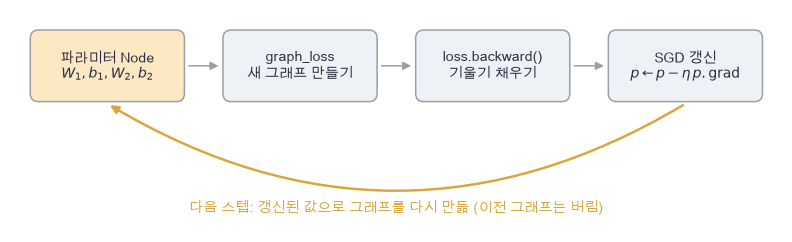

In [31]:
plot_training_cycle()

🔍 **확인** · 파라미터 Node만 스텝을 넘어 살아남고, 손실·은닉값 같은 중간 Node는 스텝마다 새로 만들어집니다. 그래서 갱신은 backward가 끝난 뒤, 다음 그래프를 만들기 전에 합니다. 아래 구현이 이 순환을 코드로 쓴 것입니다.

In [32]:
def fit_graph_mlp(X, Y, hidden_size=12, steps=1800, lr=.1, seed=131, matmul_fn=matmul):
    """엔진으로 MLP를 SGD 학습: 스텝마다 새 그래프 → backward → 갱신. X: (N, D), Y: (N, K) → (파라미터 Node 목록, 손실 기록 (steps+1,))."""
    # 쓰는 것: Node (3절) · graph_loss (4절) · matmul (3절)
    local_rng = np.random.default_rng(seed)
    D, K = X.shape[1], Y.shape[1]
    values = [local_rng.normal(size=(D, hidden_size)), np.zeros(hidden_size),
              local_rng.normal(size=(hidden_size, K)) * .2, np.zeros(K)]   # W1, b1, W2, b2 시작값
    params = [Node(value) for value in values]              # 파라미터 Node만 스텝을 넘어 살아남음
    history = []
    for step in range(steps):
        loss = graph_loss(X, Y, params, matmul_fn)          # 1. 현재 파라미터로 그래프를 새로 만듦
        history.append(float(loss.data))
        loss.backward()                                     # 2. 이 그래프의 기울기
        for parameter in params:
            parameter.data -= lr * parameter.grad           # 3. SGD 갱신
    history.append(float(graph_loss(X, Y, params, matmul_fn).data))   # 마지막 갱신 뒤의 손실
    return params, np.array(history)

In [33]:
# 쓰는 것: rng (4절 검산 셀) · graph_prediction (4절)
X_train = np.linspace(-1, 1, 64)[:, None]                   # (64, 1): 학습 입력
Y_train = np.sin(np.pi * X_train) + rng.normal(size=(64, 1)) * .04   # (64, 1): sin(πx) + 잡음
X_valid = rng.uniform(-1, 1, size=(128, 1))                 # (128, 1): 검증 입력 (다른 위치)
Y_valid = np.sin(np.pi * X_valid) + rng.normal(size=(128, 1)) * .04
trained_parameters, train_history = fit_graph_mlp(X_train, Y_train)
valid_prediction = graph_prediction(X_valid, trained_parameters).data   # (128, 1): 학습한 파라미터로 예측 (값만)
valid_half_mse = .5 * np.mean((valid_prediction - Y_valid)**2)
assert train_history[-1] < .05 * train_history[0], "학습 손실이 처음의 5% 아래로 내려가야 합니다"
assert valid_half_mse < .02, "검증 half-MSE가 0.02 아래여야 합니다"
print('학습 half-MSE:', train_history[0], '→', train_history[-1], '검증:', valid_half_mse)

학습 half-MSE: 0.7215567955122905 → 0.0037926371227293663 검증: 0.00430181688874492


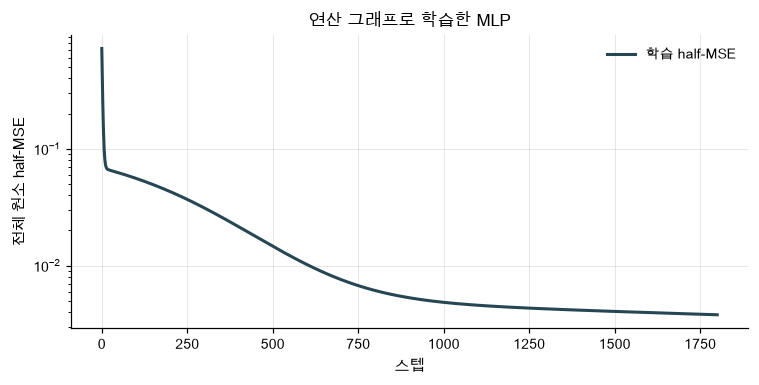

In [34]:
plot_curves(np.arange(len(train_history)), {'학습 half-MSE': train_history}, title='연산 그래프로 학습한 MLP', ylabel='전체 원소 half-MSE', logy=True)

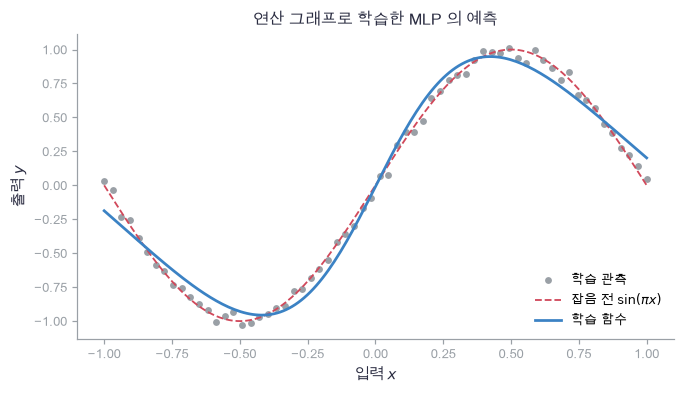

In [35]:
# 쓰는 것: graph_prediction (4절) · trained_parameters (5절 학습 셀). 그림용: 학습한 함수
grid = np.linspace(-1, 1, 180)[:, None]                     # (180, 1): 그림용 입력
grid_prediction = graph_prediction(grid, trained_parameters).data
plot_fit(X_train.ravel(), Y_train.ravel(), grid.ravel(), grid_prediction.ravel(), np.sin(np.pi * grid).ravel())

🔍 **확인** · 학습 손실이 처음의 5% 아래로 내려가고 검증 half-MSE도 0.02 아래입니다. 파란 학습 함수가 잡음 전의 $\sin(\pi x)$를 따라갑니다. 기울기의 계산을 자동화해도 모델의 구조·손실의 평균 축·학습률은 직접 정합니다.

### 🔍 stop-gradient를 숫자로 확인하기

$x=3$에서 $x\cdot x$와 $x\cdot\operatorname{stopgrad}(x)$의 값은 모두 9입니다.
앞쪽 경로만 미분하는 두 번째 계산의 기울기는 3이고, 양쪽 경로를 미분하면 6입니다.
이 연산은 표현 예측의 교사 타깃과 RL의 고정 타깃을 만들 때 연결됩니다. 값을 복사해 새 Node로 만드는 것이 이 엔진의 해당 동작입니다.

> **코드**
>
> - `Node(live.data)`: 값만 복사한 새 잎 Node. 원래 `live`와 부모 관계가 없어 기울기가 그쪽으로 흐르지 않습니다.
> - `pt.detach()`: PyTorch에서 같은 일. 값은 같지만 그래프에서 떼어 낸 tensor입니다.

In [36]:
# 쓰는 것: Node (3절)
live = Node(3.)
(live * live).backward()                                    # 양쪽 경로 모두 live
full_gradient = live.grad.copy()                            # 2x = 6
(live * Node(live.data)).backward()                         # 오른쪽은 값만 복사한 새 잎: 한 경로만
stopped_gradient = live.grad.copy()                         # x = 3
pt = torch.tensor(3., dtype=torch.float64, requires_grad=True)
(pt * pt.detach()).backward()                               # PyTorch의 같은 계산
np.testing.assert_allclose([full_gradient, stopped_gradient, pt.grad.item()], [6., 3., 3.])   # 검산: 6, 3, 3
print('양쪽 경로 / 한쪽 경로:', full_gradient, stopped_gradient)

양쪽 경로 / 한쪽 경로: 6.0 3.0


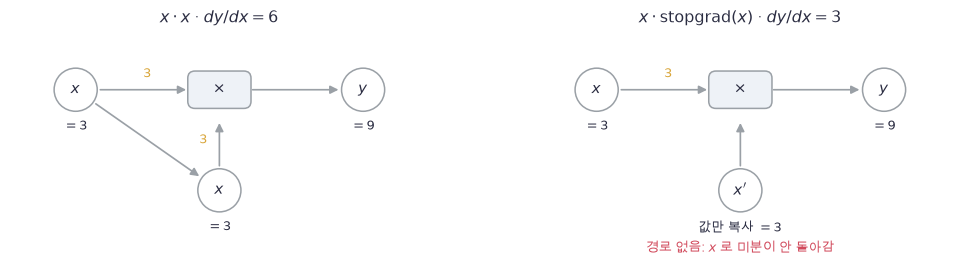

In [37]:
plot_stop_gradient(full_gradient, stopped_gradient)

🔍 **확인** · 오른쪽 그래프에서 복사한 값은 $x$와 연결되어 있지 않아 기울기가 한 경로로만 돌아가 3입니다. PyTorch의 `detach()`도 같은 3을 냅니다.

### ✏️ 연습 5 · 새 그래프 → backward → 갱신

파라미터 Node 목록 `params`로 학습 스텝 하나를 완성하세요. 그래프를 **새로** 만드는 첫 줄은 써 두었으니, 그 그래프로 기울기를 채우고 파라미터를 갱신하는 세 줄을 채웁니다. 갱신은 backward가 끝난 뒤입니다. 검사는 손으로 셀 수 있는 1×1 MLP 한 스텝과, 작은 MLP에서 4절 `manual_mlp`의 기울기로 한 스텝을 대조합니다.

In [38]:
def exercise_sgd_step(X, Y, params, lr):
    """연습 5: 학습 스텝 하나. X: (N, D), Y: (N, K), params: [W1, b1, W2, b2] Node 목록, lr: 숫자 → 갱신 전 손실값 (숫자). params는 제자리에서 갱신됩니다."""
    loss = graph_loss(X, Y, params)                             # 1. 현재 파라미터로 그래프를 새로 만듦
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 이 그래프로 기울기를 채우고(2단계), 그다음 params의 Node마다 data에서 lr · grad를 빼 갱신합니다(3단계)
    ### 힌트: 5절 fit_graph_mlp의 2·3단계입니다. 두 단계의 순서를 바꾸면 기울기가 아직 0인 채로 갱신되어 파라미터가 그대로입니다.
    raise NotImplementedError
    return float(loss.data)

In [39]:
def check_sgd_step(candidate):
    """손계산이 되는 1×1 MLP 한 스텝과, 작은 MLP에서 4절 manual_mlp와의 비교로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: Node (3절) · manual_mlp (4절)
    tiny = [Node([[1.]]), Node([0.]), Node([[1.]]), Node([0.])]  # W1, b1, W2, b2: x = 0이면 hidden = tanh(0) = 0, 예측 = b2 = 0
    first_loss = candidate(np.array([[0.]]), np.array([[2.]]), tiny, lr=.5)
    np.testing.assert_allclose(first_loss, 2.)                   # 검산: 손계산 ½·(0 − 2)² = 2
    np.testing.assert_allclose([tiny[1].data[0], tiny[3].data[0]], [1., 1.])   # 검산: db1 = db2 = −2 이므로 0 − 0.5·(−2) = 1
    np.testing.assert_allclose([tiny[0].data[0, 0], tiny[2].data[0, 0]], [1., 1.])   # 검산: x = 0, hidden = 0이라 dW1 = dW2 = 0, 그대로
    second_loss = candidate(np.array([[0.]]), np.array([[2.]]), tiny, lr=.5)
    assert second_loss < first_loss, f"갱신 뒤 새 그래프의 손실 {second_loss}은 처음 {first_loss}보다 작아야 합니다"
    rng_c = np.random.default_rng(136)
    X_c, Y_c = rng_c.normal(size=(4, 3)), rng_c.normal(size=(4, 2))
    values = [rng_c.normal(size=shape) * .3 for shape in [(3, 5), (5,), (5, 2), (2,)]]
    params_c = [Node(value) for value in values]
    loss_c = candidate(X_c, Y_c, params_c, lr=.1)
    manual_loss, manual_grads = manual_mlp(X_c, Y_c, values)
    np.testing.assert_allclose(loss_c, manual_loss)              # 검산: 갱신 전 손실 = 손으로 쓴 MLP의 손실
    for parameter, value, gradient in zip(params_c, values, manual_grads):
        np.testing.assert_allclose(parameter.data, value - .1 * gradient, atol=1e-12)   # 검산: 한 스텝 뒤 = 값 − lr·손으로 쓴 기울기
    print("학습 스텝 하나: 손계산·manual_mlp와 일치합니다.")

run_check(check_sgd_step, exercise_sgd_step, hint="loss.backward() 뒤에 for parameter in params: parameter.data -= lr * parameter.grad")

☐ exercise_sgd_step: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: loss.backward() 뒤에 for parameter in params: parameter.data -= lr * parameter.grad


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
loss.backward()
for parameter in params:
    parameter.data -= lr * parameter.grad
```

</details>

## ✏️ 6. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · broadcasting 역방향의 두 합 (2절)

기울기 `dY` $(N,D)$에서 $(D,)$ 편향의 기울기와 $(N,1)$ 열벡터의 기울기를 만드는 두 줄을 채우세요.

In [40]:
def exercise_broadcast_grads(dY):
    """연습 A: broadcasting 역방향의 두 합. dY: (N, D) → (db: (D,), dcol: (N, 1))."""
    assert dY.ndim == 2, "dY는 (N, D) 2차원이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: db = 앞 축을 합한 (D,), dcol = 둘째 축을 길이 1로 남기며 합한 (N, 1)
    ### 힌트: dY.sum(axis=0), dY.sum(axis=1, keepdims=True)
    raise NotImplementedError
    return db, dcol

In [41]:
def check_broadcast_grads(candidate):
    """2절 손계산과 본문 sum_to_shape로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: bc_upstream (2절 그림 셀) · sum_to_shape (2절)
    db_a, dcol_a = candidate(bc_upstream)
    np.testing.assert_allclose(db_a, [5., 7., 9.])                                                  # 검산: 2절 손계산 열별 합
    np.testing.assert_allclose(dcol_a, [[6.], [15.]])                                               # 검산: 행별 합
    G_c = np.random.default_rng(132).normal(size=(4, 5))
    db_c, dcol_c = candidate(G_c)
    np.testing.assert_allclose(db_c, sum_to_shape(G_c, (5,)))                                       # 검산: 본문 함수와 같음
    np.testing.assert_allclose(dcol_c, sum_to_shape(G_c, (4, 1)))                                   # 검산: (N, 1)도 같음
    print("broadcasting 역방향: 손계산·sum_to_shape 와 일치합니다.")

run_check(check_broadcast_grads, exercise_broadcast_grads, hint="db = dY.sum(axis=0); dcol = dY.sum(axis=1, keepdims=True)")

☐ exercise_broadcast_grads: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: db = dY.sum(axis=0); dcol = dY.sum(axis=1, keepdims=True)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
db = dY.sum(axis=0)
dcol = dY.sum(axis=1, keepdims=True)
```

</details>

### ✏️ 연습 B · 곱셈의 pullback (3절)

$Y=A\odot B$에서 상류 `g`와 두 입력 값으로 각 입력의 기울기를 원래 모양으로 만드는 두 줄을 채우세요.

In [42]:
def exercise_multiply_back(g, a_data, b_data):
    """연습 B: 곱셈의 pullback. g: broadcasting된 모양의 상류 기울기, a_data, b_data: 두 입력 값 → (da, db: 각 입력 모양)."""
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: da = g ⊙ b_data 를 a_data 의 모양으로 합친 것, db = g ⊙ a_data 를 b_data 의 모양으로 합친 것
    ### 힌트: sum_to_shape(g * b_data, a_data.shape)
    raise NotImplementedError
    return da, db

In [43]:
def check_multiply_back(candidate):
    """3절 그림의 곱셈 경로와 엔진의 multiply로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: rule_row, rule_column (국소 규칙 그림 셀) · Node, multiply (3절)
    da_a, db_a = candidate(np.ones((2, 3)), rule_row, rule_column)
    np.testing.assert_allclose(da_a, [[12.], [12.]])                                                # 검산: 3절 그림의 row 기울기 (곱셈 경로)
    np.testing.assert_allclose(db_a, [3., 3., 3.])                                                  # 검산: column의 곱셈 경로 몫
    rng_c = np.random.default_rng(133)
    a_c, b_c, g_c = rng_c.normal(size=(3, 1)), rng_c.normal(size=(3, 4)), rng_c.normal(size=(3, 4))
    na, nb = Node(a_c), Node(b_c)
    multiply(na, nb).backward(g_c)                                                                  # 엔진으로 같은 계산
    da_c, db_c = candidate(g_c, a_c, b_c)
    np.testing.assert_allclose(da_c, na.grad)                                                       # 검산: 엔진의 multiply 와 같음
    np.testing.assert_allclose(db_c, nb.grad)                                                       # 검산: db도 같음
    print("곱셈 pullback: 손계산·엔진과 일치합니다.")

run_check(check_multiply_back, exercise_multiply_back, hint="da = sum_to_shape(g * b_data, a_data.shape); db = sum_to_shape(g * a_data, b_data.shape)")

☐ exercise_multiply_back: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: da = sum_to_shape(g * b_data, a_data.shape); db = sum_to_shape(g * a_data, b_data.shape)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
da = sum_to_shape(g * b_data, a_data.shape)
db = sum_to_shape(g * a_data, b_data.shape)
```

</details>

### ✏️ 연습 C · tanh 연산 노드 만들기 (3절)

값·부모는 써 두었습니다. `back` 안에서 부모의 `grad`에 국소 미분을 곱한 기울기를 **더하는** 한 줄을 채우세요.

In [44]:
def exercise_tanh_node(a):
    """연습 C: tanh 연산 노드. a: Node 또는 배열 → 값 tanh(a)와 pullback을 가진 새 Node."""
    a = as_node(a)
    value = np.tanh(a.data)
    def back(g):
        """pullback: 부모 a의 grad에 국소 미분을 곱한 기울기를 더합니다."""
        ### 이 주석 아래에 다음을 구현하세요.
        ### 구현할 내용: a.grad 에 g ⊙ (1 − value²) 를 더합니다 (= 이 아니라 +=)
        ### 힌트: 3절 tanh 의 back 한 줄입니다.
        raise NotImplementedError
    return Node(value, (a,), back)

In [45]:
def check_tanh_node(candidate):
    """국소 미분과, 같은 잎을 두 번 썼을 때의 누적(+=)을 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: Node (3절)
    leaf = Node(np.array([0.5, -1., 2.]))
    out = candidate(leaf)
    assert isinstance(out, Node), "결과는 Node여야 합니다"
    assert out.parents == (leaf,), "부모는 입력 노드 하나여야 합니다"
    out.backward(np.array([1., 2., -1.]))
    np.testing.assert_allclose(leaf.grad, np.array([1., 2., -1.]) * (1 - np.tanh(leaf.data) ** 2))                 # 검산: g ⊙ (1 − tanh²)
    shared = Node(np.array([0.3, 0.7]))
    (candidate(shared) + candidate(shared)).backward(np.ones(2))
    np.testing.assert_allclose(shared.grad, 2 * (1 - np.tanh(shared.data) ** 2))                                   # 검산: 두 경로면 더해짐 (+=)
    print("tanh 노드: 국소 미분과 누적이 맞습니다.")

run_check(check_tanh_node, exercise_tanh_node, hint="a.grad += g * (1 - value ** 2)")

☐ exercise_tanh_node: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: a.grad += g * (1 - value ** 2)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
a.grad += g * (1 - value ** 2)
```

</details>

### ✏️ 연습 D · 손실의 출력 쪽 기울기 (4절)

$L=\tfrac12\,\mathrm{mean}((\hat Y-Y)^2)$에서 $\partial L/\partial\hat Y$를 만드는 한 줄을 채우세요. 전체 원소 평균이라 원소 수로 나눕니다.

In [46]:
def exercise_output_grad(prediction, Y):
    """연습 D: 손실 L = ½ mean((Ŷ − Y)²)의 출력 쪽 기울기. prediction, Y: (N, K) → (N, K)."""
    assert prediction.shape == Y.shape, "예측과 정답은 같은 모양이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: d_prediction = (prediction − Y) / 전체 원소 수
    ### 힌트: prediction.size 가 N·K 입니다.
    raise NotImplementedError
    return d_prediction

In [47]:
def check_output_grad(candidate):
    """손계산 (2, 2) 예제와 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    P_c, Y_c = np.array([[1., 2.], [3., 4.]]), np.array([[0., 2.], [1., 1.]])
    np.testing.assert_allclose(candidate(P_c, Y_c), [[0.25, 0.], [0.5, 0.75]])                                     # 검산: 손계산 잔차 / 4

    def loss_scalar():
        """검사기용: 손실값 ½ mean((P − Y)²)."""
        return 0.5 * np.mean((P_c - Y_c) ** 2)

    numeric_c = numerical_gradient(loss_scalar, P_c)
    np.testing.assert_allclose(candidate(P_c, Y_c), numeric_c, atol=1e-8)                                          # 검산: 중심차분
    print("출력 쪽 기울기: 손계산·중심차분과 일치합니다.")

run_check(check_output_grad, exercise_output_grad, hint="d_prediction = (prediction - Y) / prediction.size")

☐ exercise_output_grad: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: d_prediction = (prediction - Y) / prediction.size


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
d_prediction = (prediction - Y) / prediction.size
```

</details>

### 🔍 완성 예제 · 새 행렬곱을 실제 MLP에 넣기

아래 검사기는 후보 행렬곱을 사각 행렬·공유 입력·반복 backward·양쪽 부모·MLP 전체에 실제로 넣어 봅니다. 본문의 `matmul`로 통과시킨 뒤, `fit_graph_mlp(..., hidden_size=6)`로 너비를 바꾸어 학습해 봅니다.

In [48]:
def check_matmul(candidate):
    """행렬곱 후보를 검사: 1. 사각 행렬 값·기울기, 2. 같은 입력을 양쪽에, 3. 두 연산이 같은 입력을 공유(반복 backward), 4. 오른쪽 입력의 부모까지, 5. MLP 전체. 통과하면 문자열을 돌려줍니다."""
    # 쓰는 것: Node (3절) · graph_loss, manual_mlp (4절)
    local_rng = np.random.default_rng(137)
    # 1. 사각 행렬 두 크기에서 값과 두 기울기
    for N, D, K in [(2, 3, 4), (4, 2, 1)]:
        a, b = Node(local_rng.normal(size=(N, D))), Node(local_rng.normal(size=(D, K)))
        G = local_rng.normal(size=(N, K))
        output = candidate(a, b)
        assert isinstance(output, Node), "결과는 Node여야 합니다"
        assert output.data.shape == (N, K), f"결과 모양은 (N, K) = ({N}, {K})여야 합니다"
        np.testing.assert_allclose(output.data, a.data @ b.data)                     # 검산: 값
        output.backward(G)
        np.testing.assert_allclose(a.grad, G @ b.data.T, atol=1e-12)                 # 검산: dA = G Bᵀ
        np.testing.assert_allclose(b.grad, a.data.T @ G, atol=1e-12)                 # 검산: dB = Aᵀ G
    # 2. 같은 입력을 양쪽 부모에: 두 항을 더해야 함
    shared = Node(local_rng.normal(size=(3, 3)))
    G = local_rng.normal(size=(3, 3))
    candidate(shared, shared).backward(G)
    np.testing.assert_allclose(shared.grad, G @ shared.data.T + shared.data.T @ G, atol=1e-12)   # 검산: 두 경로의 합
    # 3. 서로 다른 두 연산에서 같은 입력을 사용하면 모든 기여를 누적합니다. 두 번 backward해도 같아야 합니다.
    a = Node(local_rng.normal(size=(2, 3)))
    b, c = Node(local_rng.normal(size=(3, 2))), Node(local_rng.normal(size=(3, 2)))
    G = local_rng.normal(size=(2, 2))
    branched = candidate(a, b) + candidate(a, c)
    for _ in range(2):
        branched.backward(G)
        np.testing.assert_allclose(a.grad, G @ (b.data+c.data).T, atol=1e-12)        # 검산: a는 두 연산의 기여 합
        np.testing.assert_allclose(b.grad, a.data.T @ G, atol=1e-12)                 # 검산: b, c는 각자 한 경로
        np.testing.assert_allclose(c.grad, a.data.T @ G, atol=1e-12)                 # 검산: c도 한 경로
    # 4. 오른쪽 입력에도 앞선 연산이 있으면 그 부모까지 역전파해야 합니다.
    root_b = Node(local_rng.normal(size=(3, 2)))
    candidate(a, root_b * 2.).backward(G)
    np.testing.assert_allclose(root_b.grad, 2*a.data.T @ G, atol=1e-12)              # 검산: 곱셈 2를 지나 root_b까지
    # 5. MLP 전체에 끼워 손으로 쓴 backward와 비교
    X, Y = local_rng.normal(size=(4, 3)), local_rng.normal(size=(4, 2))
    values = [local_rng.normal(size=s) * .2 for s in [(3, 5), (5,), (5, 2), (2,)]]
    params = [Node(value) for value in values]
    loss = graph_loss(X, Y, params, matmul_fn=candidate)
    loss.backward()
    reference_loss, reference_grads = manual_mlp(X, Y, values)
    np.testing.assert_allclose(loss.data, reference_loss, atol=1e-12)                # 검산: 손실값
    for p, reference in zip(params, reference_grads):
        np.testing.assert_allclose(p.grad, reference, atol=1e-11)                    # 검산: 네 파라미터의 기울기
    return '통과: 사각 행렬·공유 분기·반복 backward·양쪽 부모·MLP 전체 기울기'

In [49]:
# 쓰는 것: matmul (3절) · X_train, Y_train, X_valid, Y_valid (5절 학습 셀) · fit_graph_mlp (5절) · graph_prediction (4절)
print(check_matmul(matmul))
smaller_parameters, smaller_history = fit_graph_mlp(X_train, Y_train, hidden_size=6)   # 너비 12 → 6
smaller_valid = .5 * np.mean((graph_prediction(X_valid, smaller_parameters).data - Y_valid)**2)
print('hidden=6 학습 / 검증 half-MSE:', smaller_history[-1], smaller_valid)

통과: 사각 행렬·공유 분기·반복 backward·양쪽 부모·MLP 전체 기울기


hidden=6 학습 / 검증 half-MSE: 0.006918263554772793 0.007321249042379012


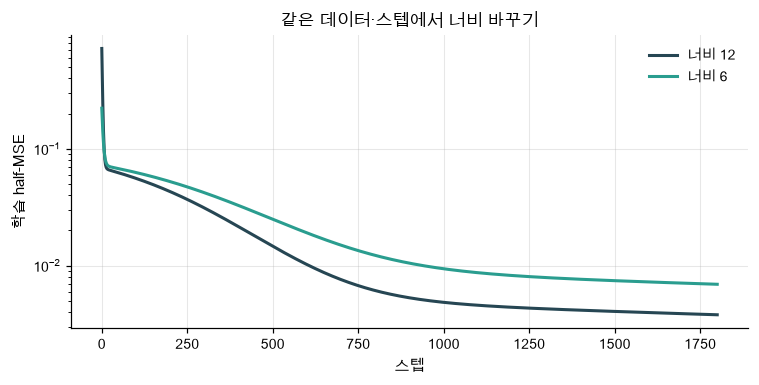

In [50]:
plot_curves(np.arange(len(train_history)), {'너비 12': train_history, '너비 6': smaller_history},
            title='같은 데이터·스텝에서 너비 바꾸기', ylabel='학습 half-MSE', logy=True)

### ✏️ 준비도 질문 · 다음으로 가기 전, 다섯 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- 공유 Node를 한 번 방문하면서도 여러 경로의 기울기를 합하는 이유를 설명할 수 있나요? → 1·3절
- `sum_to_shape`의 두 종류 합을 각각 작은 배열로 확인할 수 있나요? → 2절
- 벡터 출력의 `seed`를 바꾸면 어떤 스칼라 목적의 기울기가 되는지 쓸 수 있나요? → 1·3절
- PyTorch와 이 엔진의 기울기 초기화 위치를 찾고 한 스텝을 대조할 수 있나요? → 4절
- 새 연산에 값·부모·VJP를 붙여 전체 MLP 검산까지 통과시킬 수 있나요? → 3절

다음 [14 손실·정규화](14_losses_regularization.ipynb)에서는 계산할 목적을 바꿉니다.

📎 공식 API 참고: [PyTorch의 자동미분 안내](https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html).
이 노트북의 NumPy 엔진은 본문에 제시한 연산 범위와 초기화 규약을 따릅니다.